In [12]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_core.messages.utils import trim_messages, count_tokens_approximately
from langchain_google_genai import ChatGoogleGenerativeAI

In [13]:
load_dotenv()
llm = ChatGoogleGenerativeAI(model='models/gemini-2.5-flash')

In [14]:
def chat_node(state: MessagesState):
    messages = trim_messages(
        messages= state['messages'],
        strategy= "last",
        max_tokens=150,
        token_counter= count_tokens_approximately
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = llm.invoke(messages)
    return {"messages": [response]}

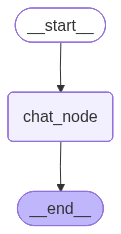

In [15]:
graph = StateGraph(MessagesState)

graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

# workflow = graph.compile()
checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

workflow

In [16]:
config = {"configurable": {"thread_id":"thread_1"}}

workflow.invoke({"messages": [{"role": "user", "content": "Hi, My name is Rathan"}]}, config=config)

Current Token Count -> 10
Hi, My name is Rathan


{'messages': [HumanMessage(content='Hi, My name is Rathan', additional_kwargs={}, response_metadata={}, id='b3d6aa10-d873-491b-a847-68ef58e290fd'),
  AIMessage(content='Hi Rathan, nice to meet you! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d695c-3f7c-7070-b7c9-ce2ef9c42280-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 43, 'total_tokens': 51, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 27}})]}

In [17]:
workflow.invoke({"messages": [{"role": "user", "content": "Tell about jaguar car"}]}, config=config)

Current Token Count -> 39
Hi, My name is Rathan
Hi Rathan, nice to meet you! How can I help you today?
Tell about jaguar car


{'messages': [HumanMessage(content='Hi, My name is Rathan', additional_kwargs={}, response_metadata={}, id='b3d6aa10-d873-491b-a847-68ef58e290fd'),
  AIMessage(content='Hi Rathan, nice to meet you! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d695c-3f7c-7070-b7c9-ce2ef9c42280-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 43, 'total_tokens': 51, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 27}}),
  HumanMessage(content='Tell about jaguar car', additional_kwargs={}, response_metadata={}, id='a1c39932-b3bd-49a4-898e-02cd628d4250'),
  AIMessage(content='Jaguar Cars is an iconic British luxury vehicle manufacturer known for its blend of **performance, luxury, and distinctive design**. It\'s a brand synonymous with elegance, speed, and a rich heritage in bot

In [18]:
workflow.invoke({"messages": [{"role": "user", "content": "Tell what is MCP server"}]}, config=config)

Current Token Count -> 10
Tell what is MCP server


{'messages': [HumanMessage(content='Hi, My name is Rathan', additional_kwargs={}, response_metadata={}, id='b3d6aa10-d873-491b-a847-68ef58e290fd'),
  AIMessage(content='Hi Rathan, nice to meet you! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d695c-3f7c-7070-b7c9-ce2ef9c42280-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 43, 'total_tokens': 51, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 27}}),
  HumanMessage(content='Tell about jaguar car', additional_kwargs={}, response_metadata={}, id='a1c39932-b3bd-49a4-898e-02cd628d4250'),
  AIMessage(content='Jaguar Cars is an iconic British luxury vehicle manufacturer known for its blend of **performance, luxury, and distinctive design**. It\'s a brand synonymous with elegance, speed, and a rich heritage in bot

In [ ]:
workflow.invoke({"messages": [{"role": "user", "content": "Tell what is AI"}]}, config=config)

Current Token Count -> 8
Tell what is AI


{'messages': [HumanMessage(content='Hi, My name is Rathan', additional_kwargs={}, response_metadata={}, id='b3d6aa10-d873-491b-a847-68ef58e290fd'),
  AIMessage(content='Hi Rathan, nice to meet you! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d695c-3f7c-7070-b7c9-ce2ef9c42280-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 43, 'total_tokens': 51, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 27}}),
  HumanMessage(content='Tell about jaguar car', additional_kwargs={}, response_metadata={}, id='a1c39932-b3bd-49a4-898e-02cd628d4250'),
  AIMessage(content='Jaguar Cars is an iconic British luxury vehicle manufacturer known for its blend of **performance, luxury, and distinctive design**. It\'s a brand synonymous with elegance, speed, and a rich heritage in bot

In [20]:
workflow.invoke({"messages": [{"role": "user", "content": "Tell who am i"}]}, config=config)

Current Token Count -> 8
Tell who am i


{'messages': [HumanMessage(content='Hi, My name is Rathan', additional_kwargs={}, response_metadata={}, id='b3d6aa10-d873-491b-a847-68ef58e290fd'),
  AIMessage(content='Hi Rathan, nice to meet you! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d695c-3f7c-7070-b7c9-ce2ef9c42280-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 43, 'total_tokens': 51, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 27}}),
  HumanMessage(content='Tell about jaguar car', additional_kwargs={}, response_metadata={}, id='a1c39932-b3bd-49a4-898e-02cd628d4250'),
  AIMessage(content='Jaguar Cars is an iconic British luxury vehicle manufacturer known for its blend of **performance, luxury, and distinctive design**. It\'s a brand synonymous with elegance, speed, and a rich heritage in bot